<a href="https://colab.research.google.com/github/RiazullJannat/ML/blob/main/Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [27]:
X = np.array([
    [1,4, 1.5, 3.8],
    [3,6, 1.0, 3.1],
    [4,7, 0.8, 3.9],
    [5,8, 0.4, 3.4],
    [7,9, 0.2, 2.8]
])

# w =[5,10,-2,0.5] , b=2.0
y = np.array([45.9 ,  76.55,  92.35, 107.9 , 128. ])

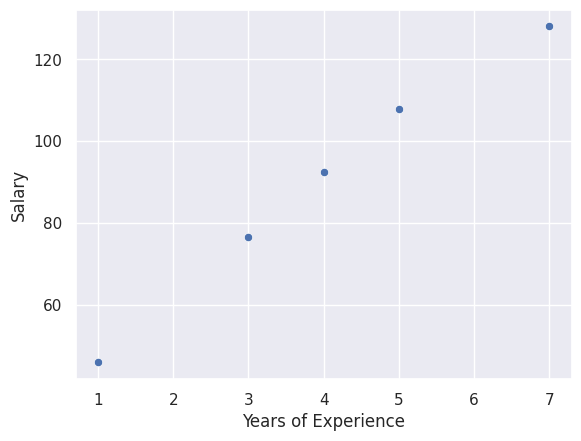

In [28]:
sns.scatterplot(x=X[:,:1].ravel(), y=y)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

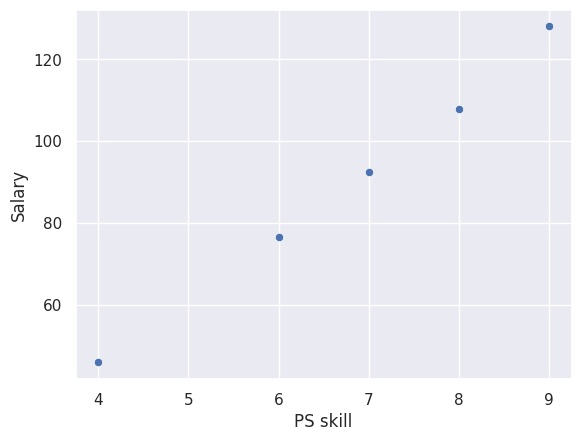

In [29]:
sns.scatterplot(x=X[:,1:2].ravel(), y=y)
plt.xlabel("PS skill")
plt.ylabel("Salary")
plt.show()

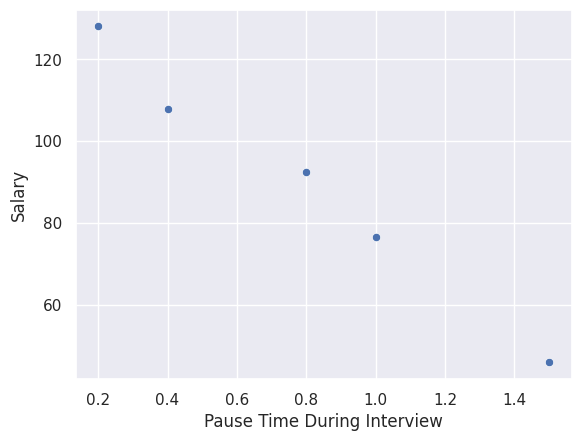

In [30]:
sns.scatterplot(x=X[:,2:3].ravel(), y=y)
plt.xlabel("Pause Time During Interview")
plt.ylabel("Salary")
plt.show()

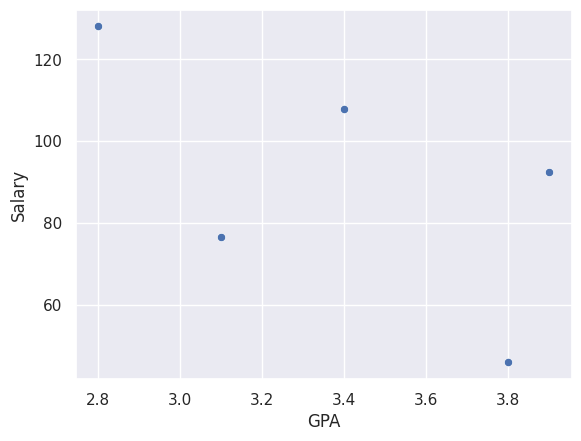

In [31]:
sns.scatterplot(x=X[:,3:].ravel(), y=y)
plt.xlabel("GPA")
plt.ylabel("Salary")
plt.show()

In [32]:
# Declearing prediction function

def make_prediction(X,W,b):
  m = X.shape[0]
  pred_list = np.zeros((m,))
  for i in range(m):
    pred_list[i]=np.dot(W,X[i]) + b
  return pred_list


In [33]:
m = X.shape[0]
n = X.shape[1]

W_init = np.ones((n))
b_init = 1.0


pred = make_prediction(X,W_init,b_init)
print(pred)

[11.3 14.1 16.7 17.8 20. ]


In [34]:
# coumpute cost

def compute_cost(X,y,W,b):
  pred_list = make_prediction(X,W,b)
  print(f"prediction: {pred_list}")
  error = (pred_list - y)**2
  print(f"error -> {error}")
  cost = np.sum(error)
  cost = cost/(2 * m)
  return cost

In [35]:
compute_cost(X,y,W_init, b_init)

prediction: [11.3 14.1 16.7 17.8 20. ]
error -> [ 1197.16    3900.0025  5722.9225  8118.01   11664.    ]


np.float64(3060.2095)

In [36]:
# import numpy as np

# # ১. ডেটাসেট এবং ইনিশিয়াল প্যারামিটার ডিফাইন করা
# X = np.array([
#     [1, 4, 1.5, 3.8],
#     [3, 6, 1.0, 3.1],
#     [4, 7, 0.8, 3.9],
#     [5, 8, 0.4, 3.4],
#     [7, 9, 0.2, 2.8]
# ])

# w = np.array([5.0, 10.0, -2.0, 0.5])
# b = 2.0
# y = np.array([45.9, 76.55, 92.35, 107.9, 128.0])

# m, n = X.shape # m = 5 (row), n = 4 (column/features)

# print("--- STEP 1: Calculation of Predictions f(x) ---")
# # f(x) = X . w + b
# f_x = np.dot(X, w) + b
# for i in range(m):
#     print(f"Sample {i+1}: f(x^{i+1}) = {f_x[i]}")

# print("\n--- STEP 2: Calculation of Errors (f(x) - y) ---")
# errors = f_x - y
# for i in range(m):
#     print(f"Sample {i+1}: Error = {f_x[i]} - {y[i]} = {errors[i]:.4f}")

# print("\n--- STEP 3: Gradient/Partial Derivative Calculation ---")
# # গ্রাডিয়েন্ট স্টোর করার জন্য একটি খালি অ্যারে (dj_dw) নেওয়া হলো
# dj_dw = np.zeros(n)

# # প্রতিটি ফিচারের (w1, w2, w3, w4) জন্য লুপ
# for j in range(n):
#     total_sum = 0
#     print(f"\nCalculating dj/dw_{j+1}:")

#     # প্রতিটি স্যাম্পলের (i=1 to m) জন্য লুপ (যা ছবিতে সাশমেন চিহ্নে দেখানো হয়েছে)
#     for i in range(m):
#         term = errors[i] * X[i, j]
#         total_sum += term
#         print(f"  Sample {i+1}: (Error: {errors[i]:.2f}) * (x_{j+1}: {X[i, j]}) = {term:.4f}")

#     dj_dw[j] = total_sum / m
#     print(f"-> Final dj/dw_{j+1} = (1/{m}) * {total_sum:.4f} = {dj_dw[j]:.4f}")

# # ইন্টারসেপ্ট বা b এর গ্রাডিয়েন্ট (dj_db)
# dj_db = np.sum(errors) / m
# print(f"\nFinal dj/db = {dj_db:.4f}")

In [37]:
def calculate_greadient(X,y,W,b):
  m = X.shape[0]
  n = X.shape[1]

  dj_dw = np.zeros(n)
  dj_db = 0.0

  predction = make_prediction(X,W,b)
  error = predction - y
  for j in range(n):
    total_sum = 0

    for i in range(m):
      term = error[i] * X[i,j]
      total_sum+=term
    dj_dw[j] = total_sum/m

  dj_db = np.sum(error) / m
  return dj_dw, dj_db

In [38]:
calculate_greadient(X,y,W_init, b_init)

(array([-346.21 , -547.09 ,  -46.502, -245.77 ]), np.float64(-74.16))

In [39]:
def gradient_descent(X,y, W_input, b_input,max_iter,alpha=0.01):
  w=W_input
  b=b_input


  for i in range(max_iter):
     # 1. Calculate the gradients (the slope)
    dj_dw, dj_db = calculate_greadient(X, y, w, b)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

  return w,b

In [40]:
W_init = np.zeros((n,))
b_init = 0.0

w_final, b_final = gradient_descent(X, y, W_input=W_init, b_input=b_init, max_iter=100000, alpha=0.01)
print(w_final, b_final)

[ 4.9736024  10.14304775 -1.56445471  0.47744225] 0.8695947679498179


In [41]:
make_prediction(X,w_final,b_final)

array([ 45.88298663,  76.56430469,  92.37579958, 107.87951048,
       127.99618862])

# Implementing with sklearn

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

In [43]:
model = LinearRegression()
model.fit(X,y)
model.score(X,y)
w=model.coef_
b=model.intercept_
print(w)
print(b)

[ 5.  10.  -2.   0.5]
2.000000000000142


In [44]:
model2 = SGDRegressor(penalty=None,max_iter=10000000,learning_rate="constant")

model2.fit(X,y)


weights= model2.coef_
bias = model2.intercept_

print(weights)
print(bias)

[ 6.83742565  8.44418352 -0.29434943  1.47663797]
[0.7634121]
